# Final Portfolio Project - Classification Task
# Heart Disease Prediction

**Student Name:** Srijan Pokhrel  
**UID:** 2548386  
**Course:** Concepts and Technologies of AI (5CS037)  
**Module:** Final Portfolio Project  

---
## Task 1: Exploratory Data Analysis and Data Understanding

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, chi2, f_classif
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Load the dataset
df = pd.read_csv('/content/heart_disease (2).csv')

# Display basic information
print('Shape of dataset:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape of dataset: (10000, 21)

First 5 rows:


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Dataset info
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar 

In [ ]:
# Check for missing values
print('Missing Values per Column:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct.round(2)})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print(f'Total records: {len(df)}')
print(f'Total features: {df.shape[1]}')

Missing Values per Column:
                      Missing Count  Percentage (%)
Age                              29            0.29
Gender                           19            0.19
Blood Pressure                   19            0.19
Cholesterol Level                30            0.30
Exercise Habits                  25            0.25
Smoking                          25            0.25
Family Heart Disease             21            0.21
Diabetes                         30            0.30
BMI                              22            0.22
High Blood Pressure              26            0.26
Low HDL Cholesterol              25            0.25
High LDL Cholesterol             26            0.26
Alcohol Consumption            2586           25.86
Stress Level                     22            0.22
Sleep Hours                      25            0.25
Sugar Consumption                30            0.30
Triglyceride Level               26            0.26
Fasting Blood Sugar              22  

In [ ]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

# Check data types
print('\nData Types:')
print(df.dtypes)

# Target variable distribution
print('\nTarget Variable (Heart Disease Status) Distribution:')
print(df['Heart Disease Status'].value_counts())
print(f'\nClass proportions:')
print(df['Heart Disease Status'].value_counts(normalize=True).round(4))

Duplicate rows: 0

Data Types:
Age                     float64
Gender                   object
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits          object
Smoking                  object
Family Heart Disease     object
Diabetes                 object
BMI                     float64
High Blood Pressure      object
Low HDL Cholesterol      object
High LDL Cholesterol     object
Alcohol Consumption      object
Stress Level             object
Sleep Hours             float64
Sugar Consumption        object
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status     object
dtype: object

Target Variable (Heart Disease Status) Distribution:
Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Class proportions:
Heart Disease Status
No     0.8
Yes    0.2
Name: proportion, dtype: float64


### 1.2 Exploratory Data Analysis (EDA)

#### (a) Data Cleaning and Preprocessing

In [ ]:
# Handle missing values
# For numerical columns, fill with median
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'{col}: filled {df[col].isnull().sum()} missing values with median ({median_val:.2f})')

# For categorical columns, fill with mode
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Heart Disease Status')  # Don't fill target

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'{col}: filled missing values with mode ({mode_val})')

# Drop any remaining rows with missing target
df = df.dropna(subset=['Heart Disease Status'])

print(f'\nTotal missing values after cleaning: {df.isnull().sum().sum()}')
print(f'Dataset shape after cleaning: {df.shape}')

Age: filled 0 missing values with median (49.00)
Blood Pressure: filled 0 missing values with median (150.00)
Cholesterol Level: filled 0 missing values with median (226.00)
BMI: filled 0 missing values with median (29.08)
Sleep Hours: filled 0 missing values with median (7.00)
Triglyceride Level: filled 0 missing values with median (250.00)
Fasting Blood Sugar: filled 0 missing values with median (120.00)
CRP Level: filled 0 missing values with median (7.47)
Homocysteine Level: filled 0 missing values with median (12.41)
Gender: filled missing values with mode (Male)
Exercise Habits: filled missing values with mode (High)
Smoking: filled missing values with mode (Yes)
Family Heart Disease: filled missing values with mode (No)
Diabetes: filled missing values with mode (No)
High Blood Pressure: filled missing values with mode (Yes)
Low HDL Cholesterol: filled missing values with mode (Yes)
High LDL Cholesterol: filled missing values with mode (No)
Alcohol Consumption: filled missing val

In [ ]:
# Summary statistics
print('Summary Statistics for Numerical Columns:')
df.describe().round(2)

Summary Statistics for Numerical Columns:


,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,49.30,149.76,225.43,29.08,6.99,250.73,120.14,7.47,12.46
std,18.17,17.56,43.51,6.30,1.75,86.95,23.56,4.33,4.32
min,18.00,120.00,150.00,18.00,4.00,100.00,80.00,0.00,5.00
25%,34.00,134.00,187.00,23.67,5.46,176.00,99.00,3.68,8.73
50%,49.00,150.00,226.00,29.08,7.00,250.00,120.00,7.47,12.41
75%,65.00,165.00,263.00,34.51,8.53,326.00,141.00,11.24,16.13
max,80.00,180.00,300.00,40.00,10.00,400.00,160.00,15.00,20.00


In [ ]:
# Display unique values for categorical columns
print('Unique values in categorical columns:')
for col in categorical_cols:
    print(f'\n{col}: {df[col].unique()}')

Unique values in categorical columns:

Gender: ['Male' 'Female']

Exercise Habits: ['High' 'Low' 'Medium']

Smoking: ['Yes' 'No']

Family Heart Disease: ['Yes' 'No']

Diabetes: ['No' 'Yes']

High Blood Pressure: ['Yes' 'No']

Low HDL Cholesterol: ['Yes' 'No']

High LDL Cholesterol: ['No' 'Yes']

Alcohol Consumption: ['High' 'Medium' 'Low']

Stress Level: ['Medium' 'High' 'Low']

Sugar Consumption: ['Medium' 'Low' 'High']


#### (b) Visualizations to Summarize, Explore, and Understand the Data

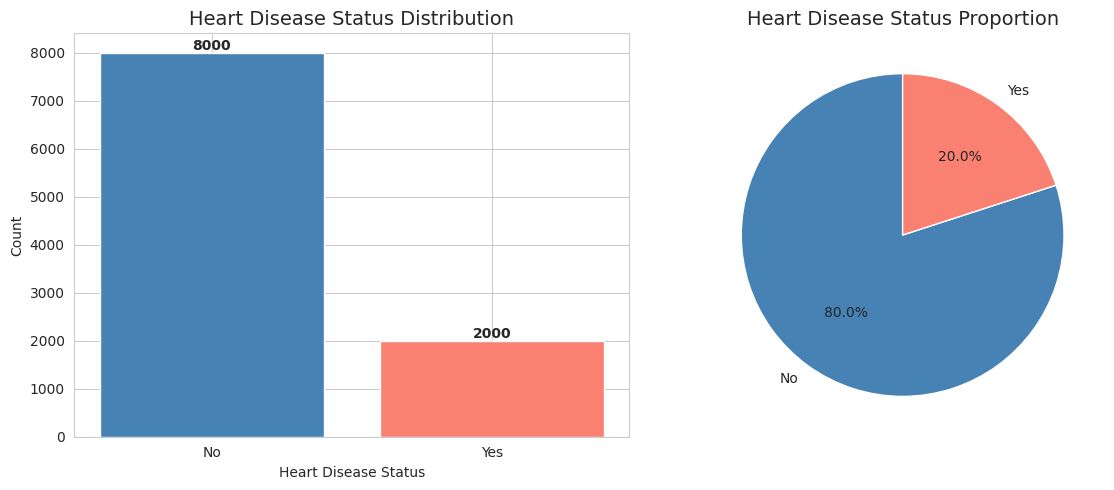

In [ ]:
# 1. Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts = df['Heart Disease Status'].value_counts()
axes[0].bar(target_counts.index, target_counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Heart Disease Status Distribution', fontsize=14)
axes[0].set_xlabel('Heart Disease Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Heart Disease Status Proportion', fontsize=14)

plt.tight_layout()
plt.show()

**Insight:** The class distribution of the target variable is examined to check for class imbalance. A balanced dataset is ideal for training classification models.

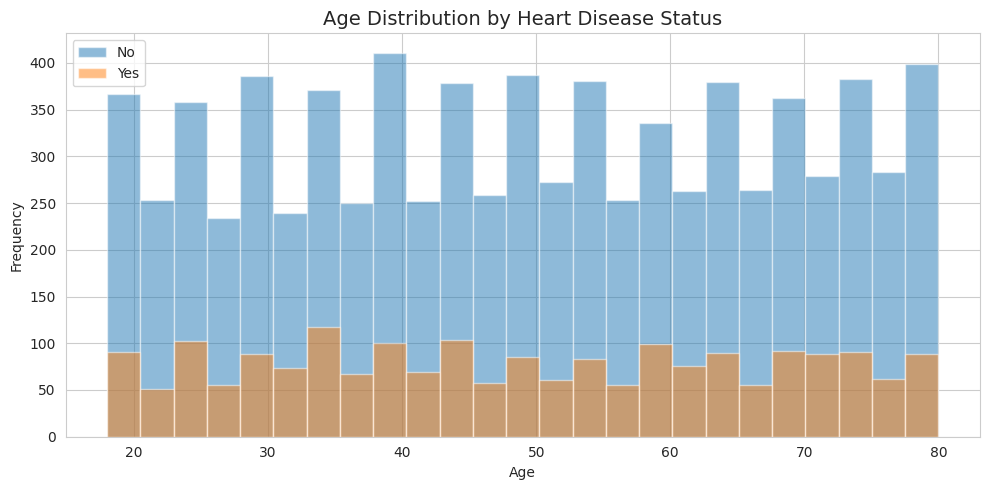

In [ ]:
# 2. Age Distribution by Heart Disease Status
plt.figure(figsize=(10, 5))
for status in df['Heart Disease Status'].unique():
    subset = df[df['Heart Disease Status'] == status]['Age']
    plt.hist(subset, bins=25, alpha=0.5, label=status)

plt.title('Age Distribution by Heart Disease Status', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** This histogram compares the age distribution between patients with and without heart disease. It helps identify whether age is a distinguishing factor for heart disease.

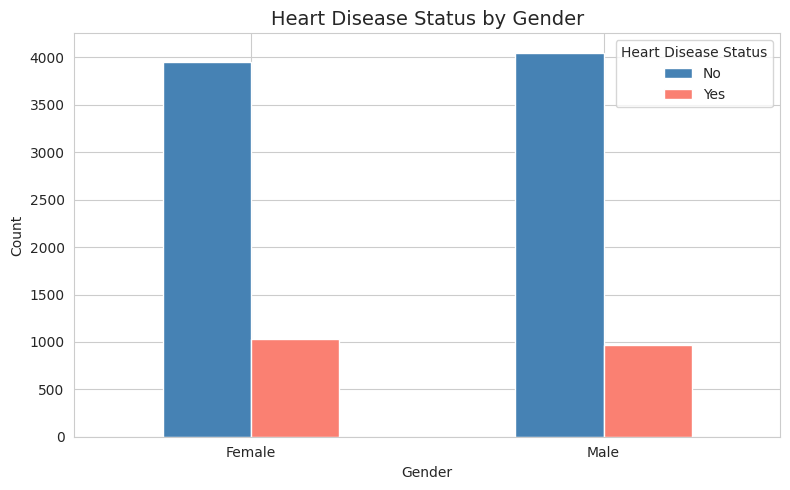

In [ ]:
# 3. Heart Disease by Gender
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df['Gender'], df['Heart Disease Status'])
ct.plot(kind='bar', color=['steelblue', 'salmon'], ax=plt.gca())
plt.title('Heart Disease Status by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Heart Disease Status')
plt.tight_layout()
plt.show()

**Insight:** This bar chart compares heart disease prevalence between genders. It helps understand if gender is a significant factor in heart disease risk.

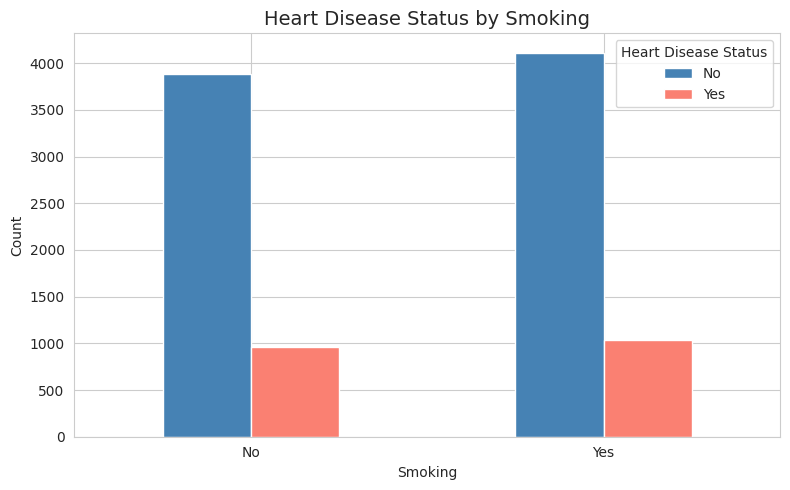

In [ ]:
# 4. Heart Disease by Smoking Status
plt.figure(figsize=(8, 5))
ct_smoke = pd.crosstab(df['Smoking'], df['Heart Disease Status'])
ct_smoke.plot(kind='bar', color=['steelblue', 'salmon'], ax=plt.gca())
plt.title('Heart Disease Status by Smoking', fontsize=14)
plt.xlabel('Smoking')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Heart Disease Status')
plt.tight_layout()
plt.show()

**Insight:** The bar chart reveals the relationship between smoking status and heart disease. This helps identify whether smoking is a risk factor in this dataset.

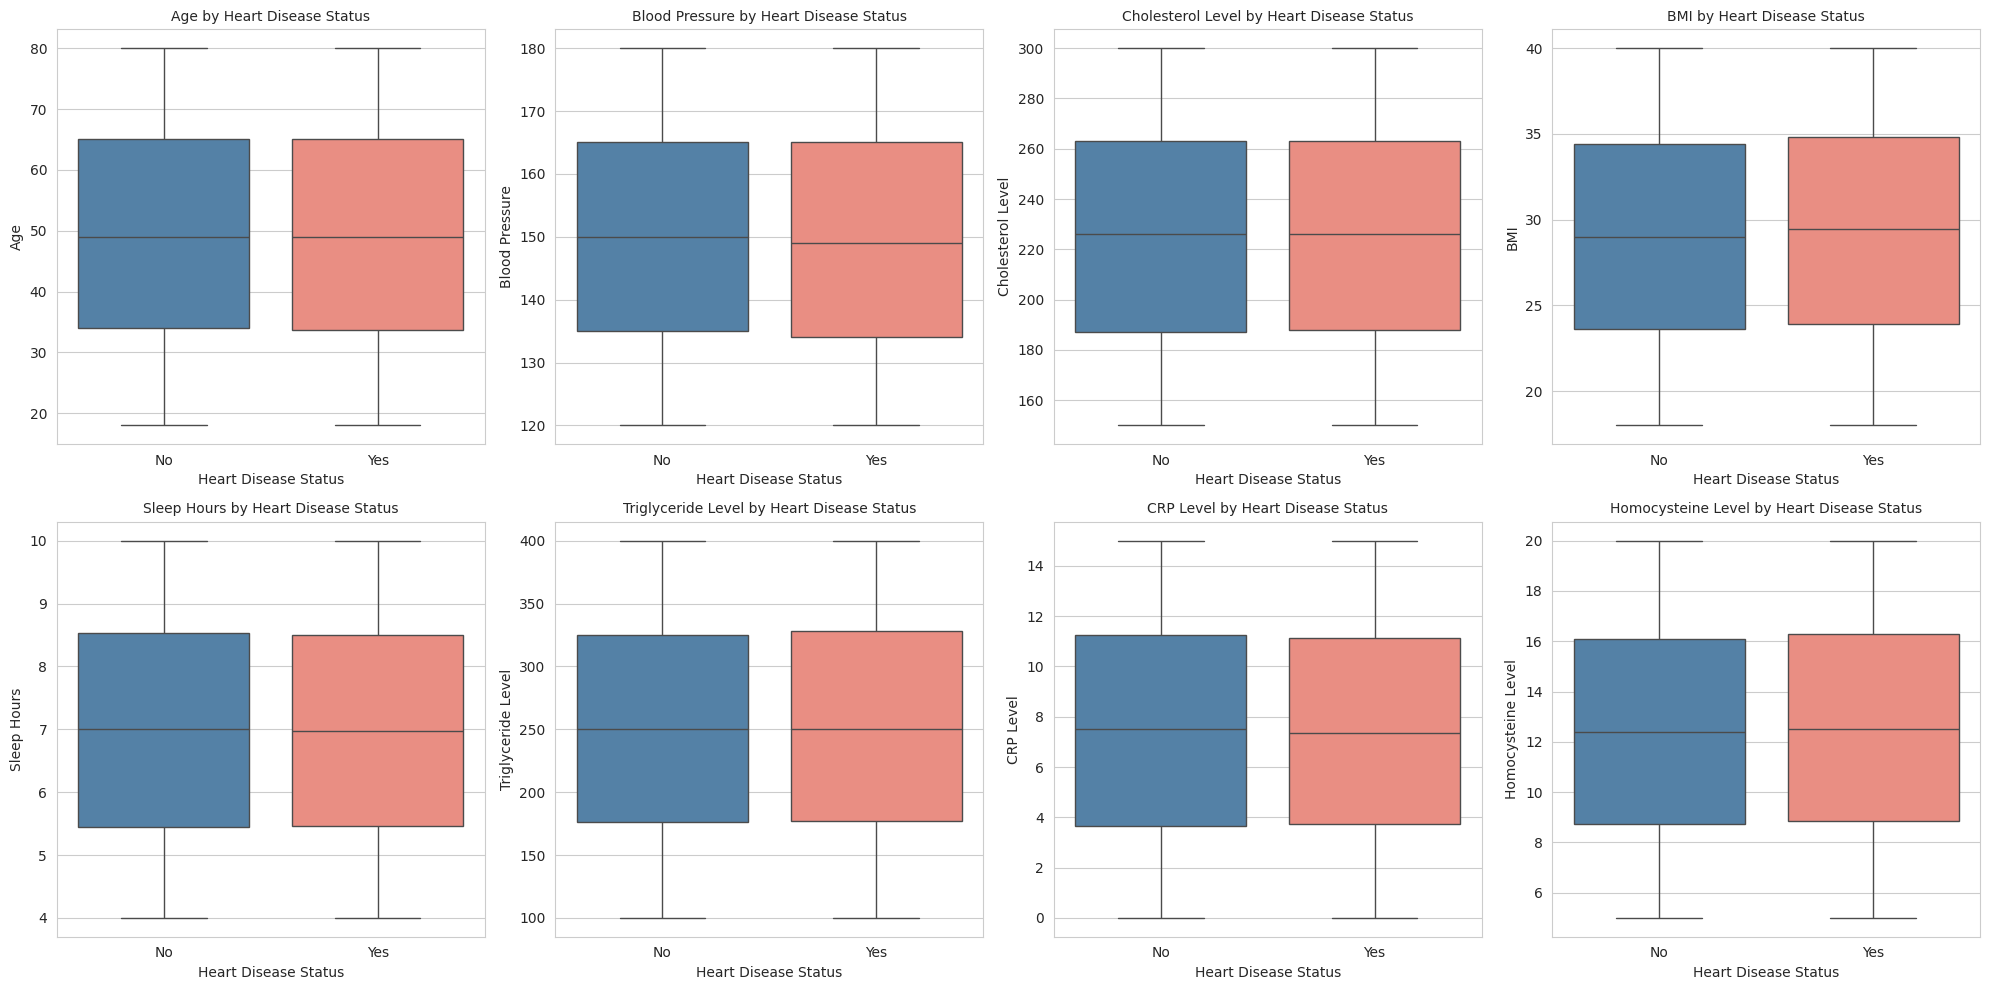

In [ ]:
# 5. Box plots of numerical features by Heart Disease Status
num_features = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI',
                'Sleep Hours', 'Triglyceride Level', 'CRP Level', 'Homocysteine Level']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, feature in enumerate(num_features):
    if feature in df.columns:
        sns.boxplot(x='Heart Disease Status', y=feature, data=df,
                    palette=['steelblue', 'salmon'], ax=axes[i])
        axes[i].set_title(f'{feature} by Heart Disease Status', fontsize=10)

plt.tight_layout()
plt.show()

**Insight:** Box plots compare the distributions of key numerical features between heart disease positive and negative groups. Features showing noticeable differences between groups are likely important predictors.

In [ ]:
# Encode all categorical variables for correlation analysis
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Exercise Habits: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Smoking: {'No': np.int64(0), 'Yes': np.int64(1)}
Family Heart Disease: {'No': np.int64(0), 'Yes': np.int64(1)}
Diabetes: {'No': np.int64(0), 'Yes': np.int64(1)}
High Blood Pressure: {'No': np.int64(0), 'Yes': np.int64(1)}
Low HDL Cholesterol: {'No': np.int64(0), 'Yes': np.int64(1)}
High LDL Cholesterol: {'No': np.int64(0), 'Yes': np.int64(1)}
Alcohol Consumption: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Stress Level: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Sugar Consumption: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Heart Disease Status: {'No': np.int64(0), 'Yes': np.int64(1)}


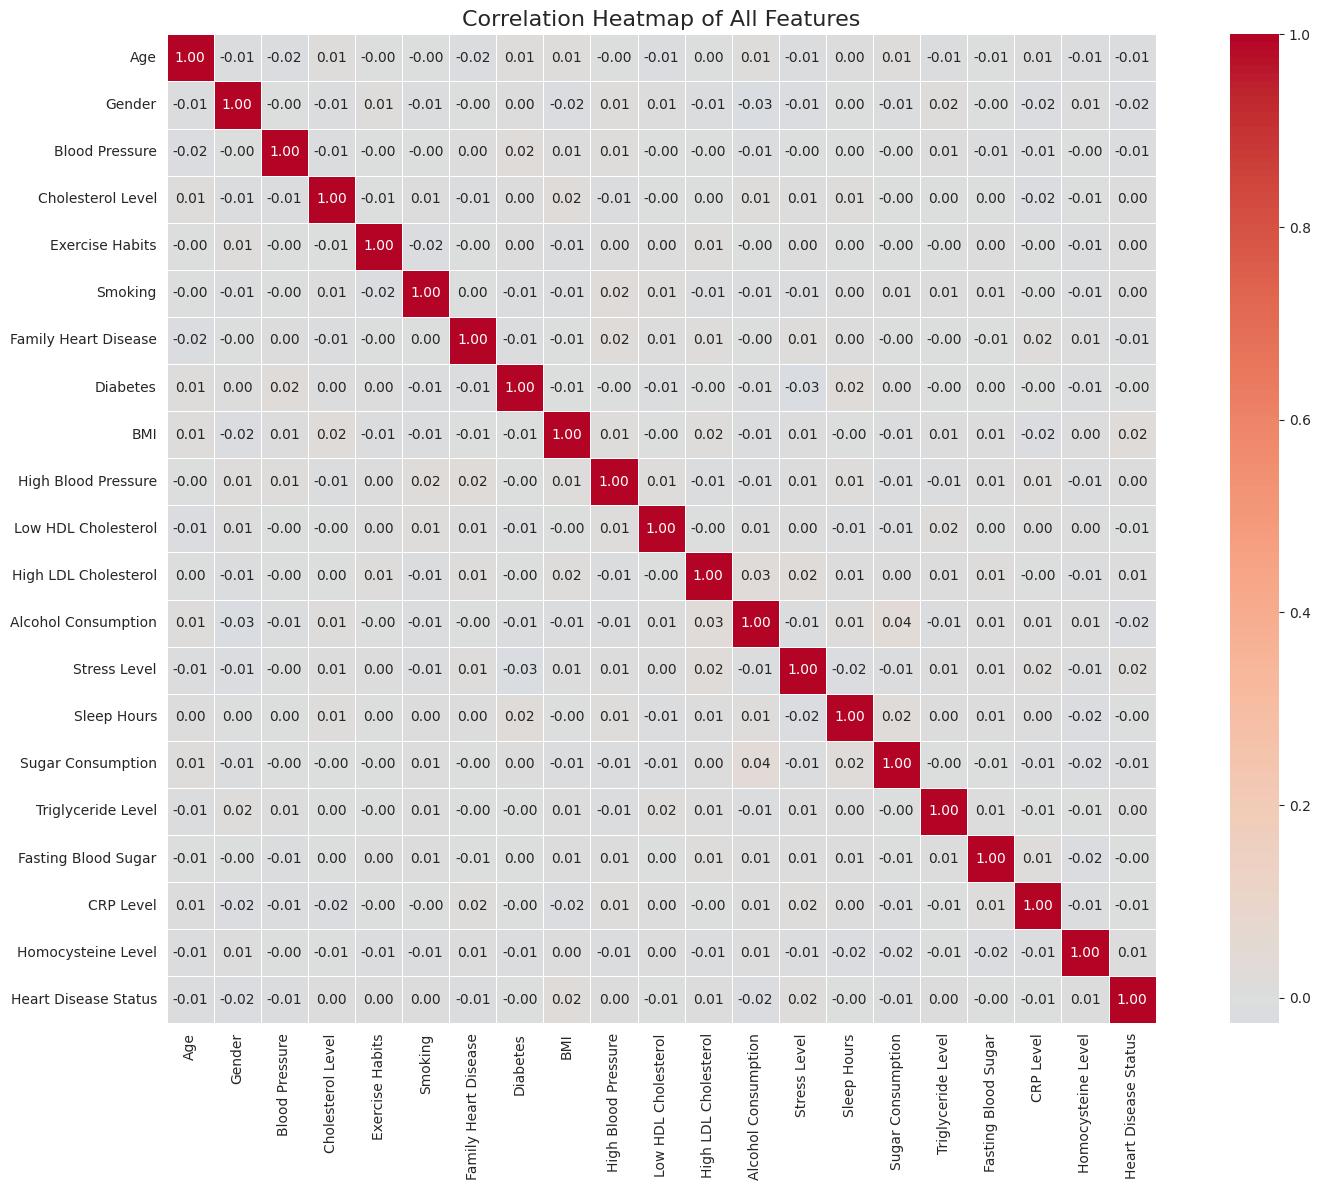

In [ ]:
# 6. Correlation Heatmap
plt.figure(figsize=(16, 12))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.tight_layout()
plt.show()

**Insight:** The correlation heatmap identifies linear relationships between features and the target variable. Features with higher absolute correlation with Heart Disease Status are potentially better predictors.

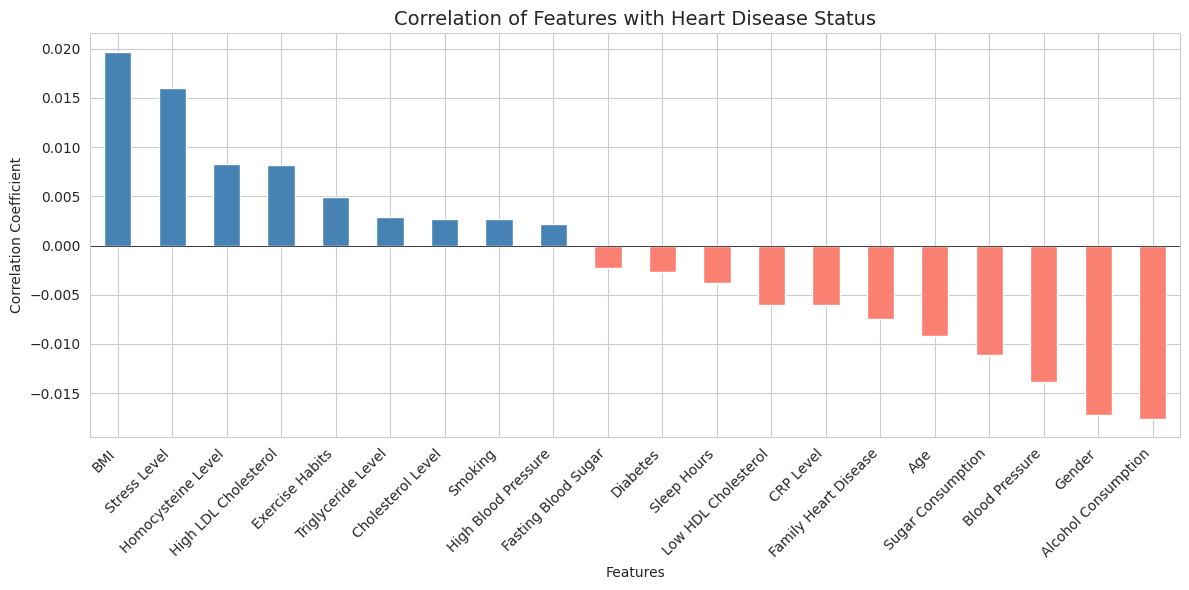

Top 5 positively correlated features:
BMI                     0.019682
Stress Level            0.016030
Homocysteine Level      0.008302
High LDL Cholesterol    0.008201
Exercise Habits         0.004876
Name: Heart Disease Status, dtype: float64

Top 5 negatively correlated features:
Age                   -0.009231
Sugar Consumption     -0.011096
Blood Pressure        -0.013876
Gender                -0.017200
Alcohol Consumption   -0.017578
Name: Heart Disease Status, dtype: float64


In [ ]:
# 7. Correlation of features with target
target_corr = correlation_matrix['Heart Disease Status'].drop('Heart Disease Status').sort_values(ascending=False)
plt.figure(figsize=(12, 6))
target_corr.plot(kind='bar', color=['steelblue' if x >= 0 else 'salmon' for x in target_corr])
plt.title('Correlation of Features with Heart Disease Status', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Top 5 positively correlated features:')
print(target_corr.head())
print('\nTop 5 negatively correlated features:')
print(target_corr.tail())

**Insight:** This bar chart shows which features have the strongest linear relationship with heart disease. Features with higher absolute correlation values are more likely to be useful in classification models.

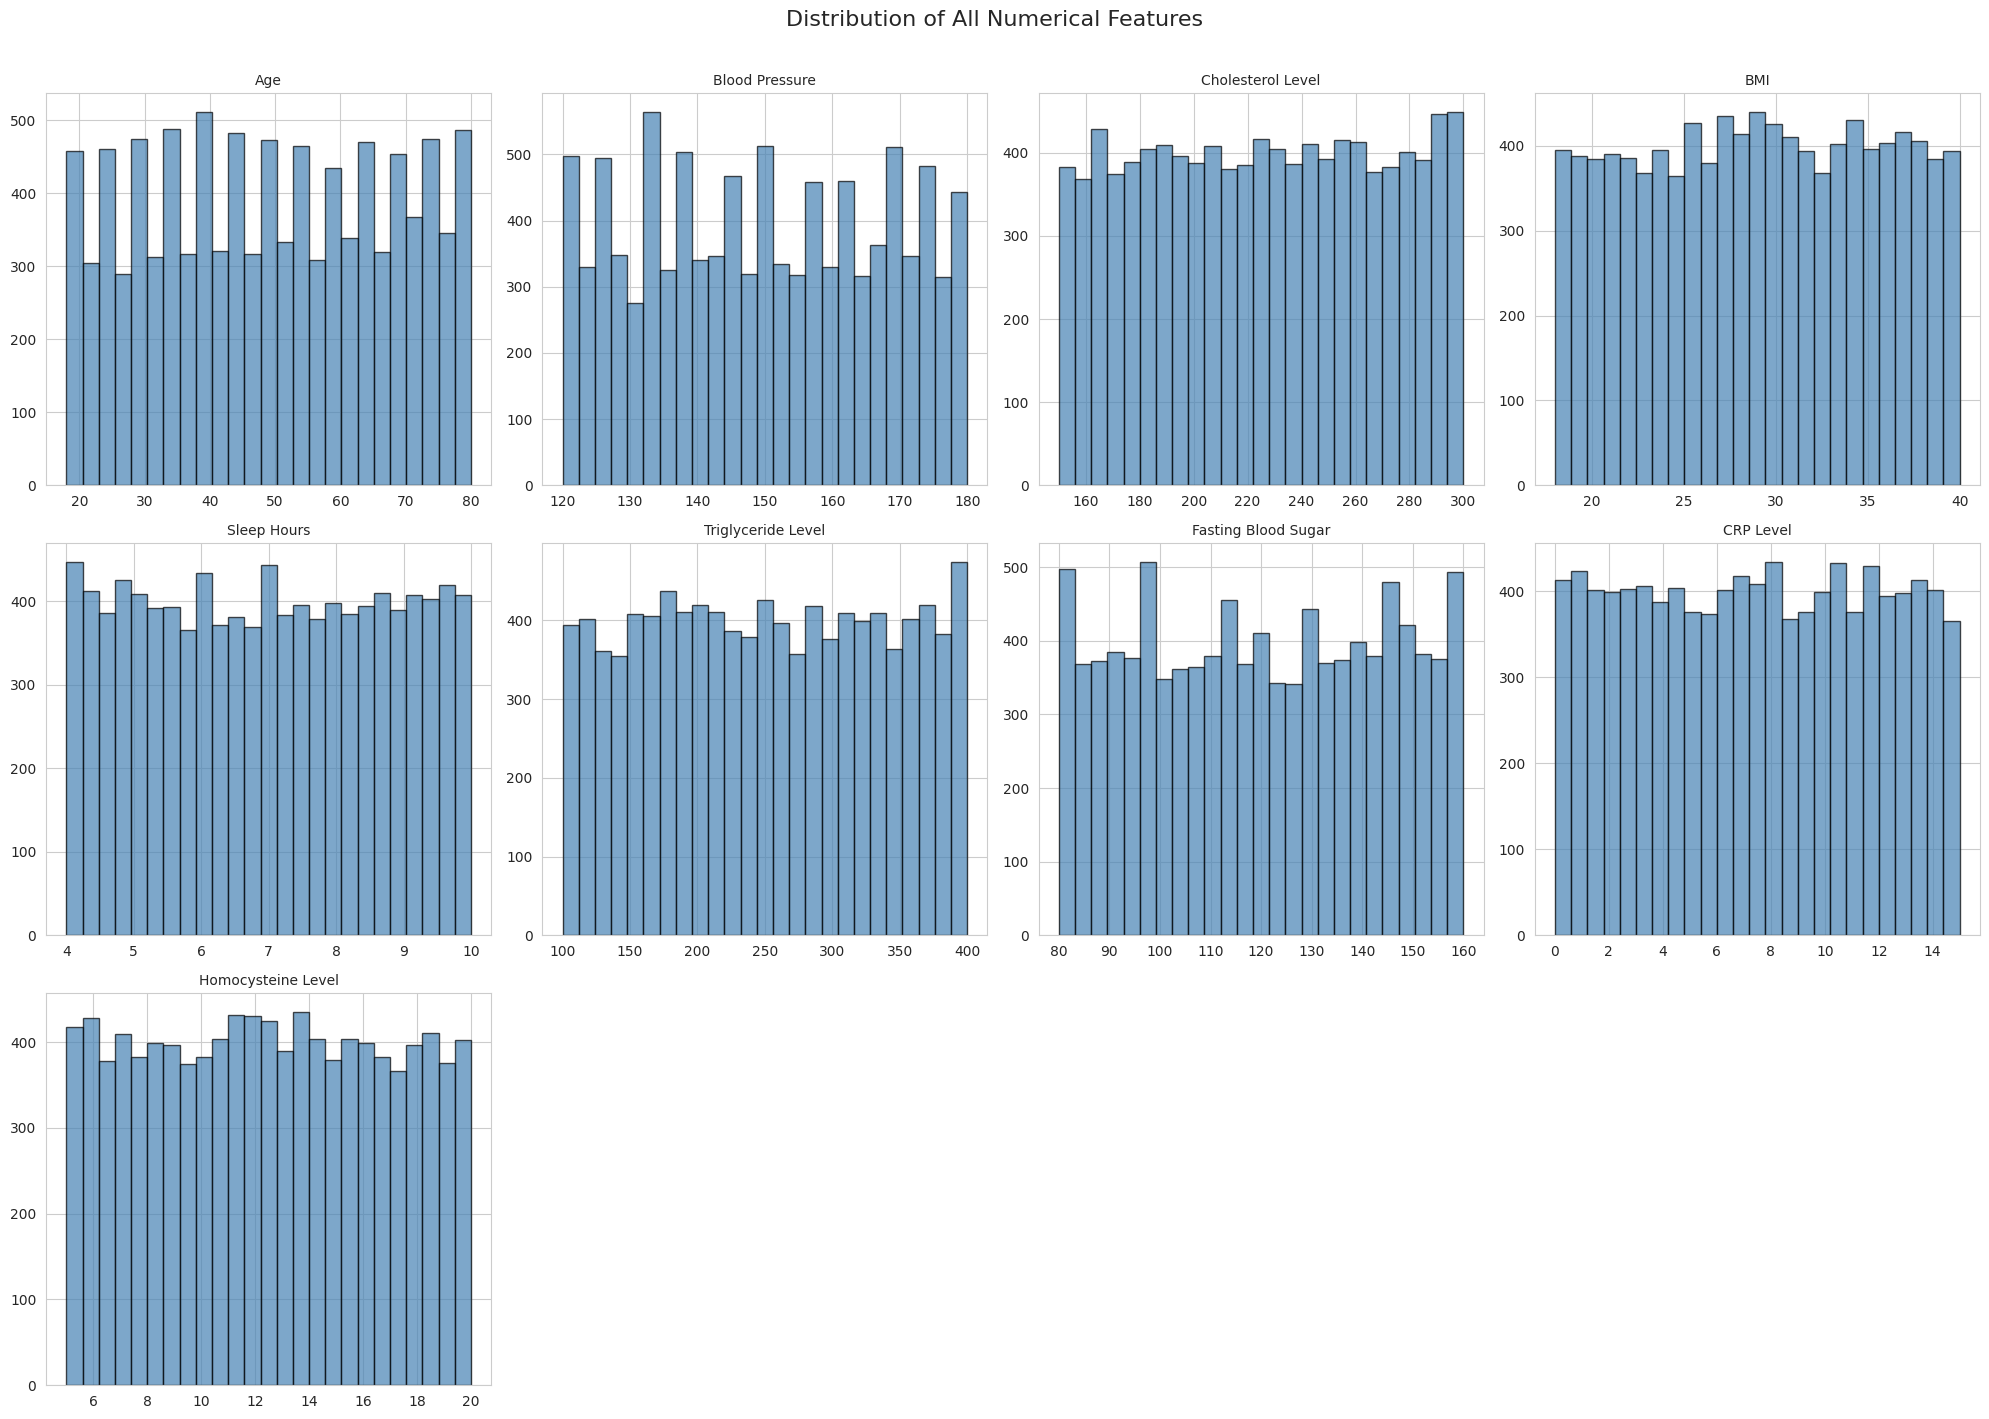

In [ ]:
# 8. Distribution of numerical features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    if i < len(axes):
        axes[i].hist(df[col], bins=25, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_title(col, fontsize=10)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distribution of All Numerical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Insight:** These histograms show the distribution of each numerical feature. Understanding feature distributions aids in selecting appropriate preprocessing steps (e.g., scaling, transformation).



# Task 2: Build a Neural Network Model


In [ ]:
# Prepare features and target using the encoded dataframe
X = df_encoded.drop('Heart Disease Status', axis=1)
y = df_encoded['Heart Disease Status']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Feature names: {list(X.columns)}')
print(f'\nTarget class distribution:')
print(y.value_counts())

Features shape: (10000, 20)
Target shape: (10000,)
Feature names: ['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

Target class distribution:
Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')
print(f'\nTraining class distribution:\n{y_train.value_counts()}')
print(f'\nTesting class distribution:\n{y_test.value_counts()}')

Training set size: 8000
Testing set size: 2000

Training class distribution:
Heart Disease Status
0    6400
1    1600
Name: count, dtype: int64

Testing class distribution:
Heart Disease Status
0    1600
1     400
Name: count, dtype: int64


In [ ]:
# Scale features for Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling applied using StandardScaler.')

Feature scaling applied using StandardScaler.


In [ ]:
# Build and train the Neural Network
nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)
print('Neural Network model trained successfully.')

Neural Network model trained successfully.


In [ ]:
# Evaluate Neural Network on Training Set
y_train_pred_nn = nn_model.predict(X_train_scaled)
print('=== Neural Network - Training Set Performance ===')
print(f'Accuracy:  {accuracy_score(y_train, y_train_pred_nn):.4f}')
print(f'Precision: {precision_score(y_train, y_train_pred_nn, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_train, y_train_pred_nn, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_train, y_train_pred_nn, average="weighted"):.4f}')
print('\nClassification Report (Training):')
print(classification_report(y_train, y_train_pred_nn))

=== Neural Network - Training Set Performance ===
Accuracy:  0.8000
Precision: 0.6400
Recall:    0.8000
F1-Score:  0.7111

Classification Report (Training):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6400
           1       0.00      0.00      0.00      1600

    accuracy                           0.80      8000
   macro avg       0.40      0.50      0.44      8000
weighted avg       0.64      0.80      0.71      8000



In [ ]:
# Evaluate Neural Network on Test Set
y_test_pred_nn = nn_model.predict(X_test_scaled)
print('=== Neural Network - Test Set Performance ===')
print(f'Accuracy:  {accuracy_score(y_test, y_test_pred_nn):.4f}')
print(f'Precision: {precision_score(y_test, y_test_pred_nn, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_test_pred_nn, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_test_pred_nn, average="weighted"):.4f}')
print('\nClassification Report (Test):')
print(classification_report(y_test, y_test_pred_nn))

=== Neural Network - Test Set Performance ===
Accuracy:  0.8000
Precision: 0.6400
Recall:    0.8000
F1-Score:  0.7111

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1600
           1       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



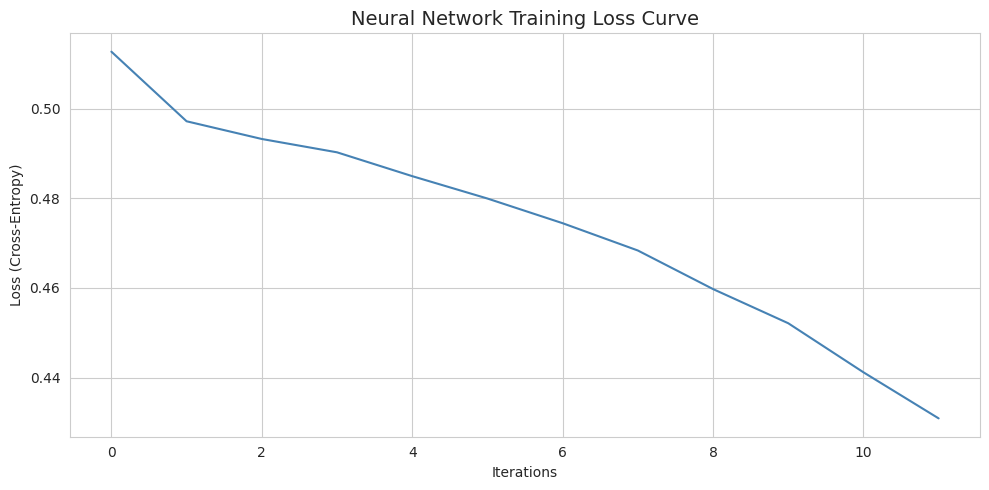

In [ ]:
# Training loss curve
plt.figure(figsize=(10, 5))
plt.plot(nn_model.loss_curve_, color='steelblue')
plt.title('Neural Network Training Loss Curve', fontsize=14)
plt.xlabel('Iterations')
plt.ylabel('Loss (Cross-Entropy)')
plt.tight_layout()
plt.show()

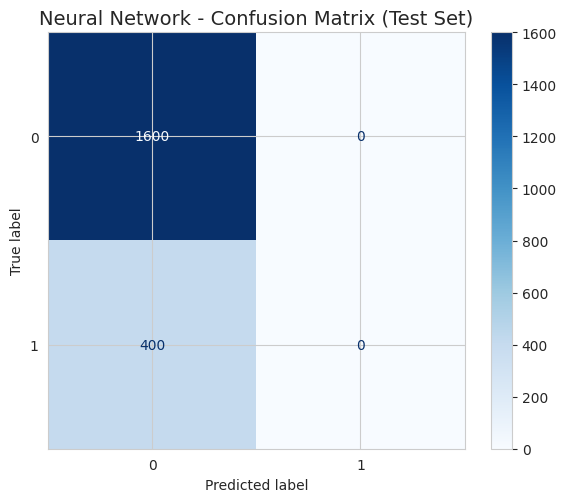

In [ ]:
# Confusion Matrix for Neural Network
fig, ax = plt.subplots(figsize=(6, 5))
cm_nn = confusion_matrix(y_test, y_test_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Neural Network - Confusion Matrix (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

# Task 3: Build Primary Model

Two classical classification models are selected:
1. **Logistic Regression** - A simple, interpretable baseline classifier.
2. **Random Forest Classifier** - An ensemble method that can capture complex patterns.

### 3.1 Split Dataset into Training and Testing Sets

In [ ]:
# Data already split above, reusing X_train, X_test, y_train, y_test
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')
print(f'Train/Test split ratio: 80/20 (stratified)')

Training samples: 8000
Testing samples: 2000
Train/Test split ratio: 80/20 (stratified)


### 3.2 Model A: Logistic Regression

In [ ]:
# Build and train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Training set evaluation
print('=== Logistic Regression - Training Set ===')
print(f'Accuracy:  {accuracy_score(y_train, y_train_pred_lr):.4f}')
print(f'Precision: {precision_score(y_train, y_train_pred_lr, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_train, y_train_pred_lr, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_train, y_train_pred_lr, average="weighted"):.4f}')

print('\n=== Logistic Regression - Test Set ===')
print(f'Accuracy:  {accuracy_score(y_test, y_test_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_test_pred_lr, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_test_pred_lr, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_test_pred_lr, average="weighted"):.4f}')

print('\nClassification Report (Test):')
print(classification_report(y_test, y_test_pred_lr))

=== Logistic Regression - Training Set ===
Accuracy:  0.8000
Precision: 0.6400
Recall:    0.8000
F1-Score:  0.7111

=== Logistic Regression - Test Set ===
Accuracy:  0.8000
Precision: 0.6400
Recall:    0.8000
F1-Score:  0.7111

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1600
           1       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



### 3.3 Model B: Random Forest Classifier

In [ ]:
# Build and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Training set evaluation
print('=== Random Forest Classifier - Training Set ===')
print(f'Accuracy:  {accuracy_score(y_train, y_train_pred_rf):.4f}')
print(f'Precision: {precision_score(y_train, y_train_pred_rf, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_train, y_train_pred_rf, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_train, y_train_pred_rf, average="weighted"):.4f}')

print('\n=== Random Forest Classifier - Test Set ===')
print(f'Accuracy:  {accuracy_score(y_test, y_test_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_test_pred_rf, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_test_pred_rf, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_test_pred_rf, average="weighted"):.4f}')

print('\nClassification Report (Test):')
print(classification_report(y_test, y_test_pred_rf))

=== Random Forest Classifier - Training Set ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

=== Random Forest Classifier - Test Set ===
Accuracy:  0.8000
Precision: 0.6400
Recall:    0.8000
F1-Score:  0.7111

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1600
           1       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



### 3.4 Initial Comparison and Discussion

In [ ]:
# Initial comparison table
initial_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest Classifier'],
    'Train Accuracy': [
        accuracy_score(y_train, y_train_pred_lr),
        accuracy_score(y_train, y_train_pred_rf)
    ],
    'Test Accuracy': [
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_rf)
    ],
    'Test Precision': [
        precision_score(y_test, y_test_pred_lr, average='weighted'),
        precision_score(y_test, y_test_pred_rf, average='weighted')
    ],
    'Test Recall': [
        recall_score(y_test, y_test_pred_lr, average='weighted'),
        recall_score(y_test, y_test_pred_rf, average='weighted')
    ],
    'Test F1-Score': [
        f1_score(y_test, y_test_pred_lr, average='weighted'),
        f1_score(y_test, y_test_pred_rf, average='weighted')
    ]
})

print('Initial Model Comparison:')
print(initial_comparison.to_string(index=False))

Initial Model Comparison:
                   Model  Train Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1-Score
     Logistic Regression             0.8            0.8            0.64          0.8       0.711111
Random Forest Classifier             1.0            0.8            0.64          0.8       0.711111


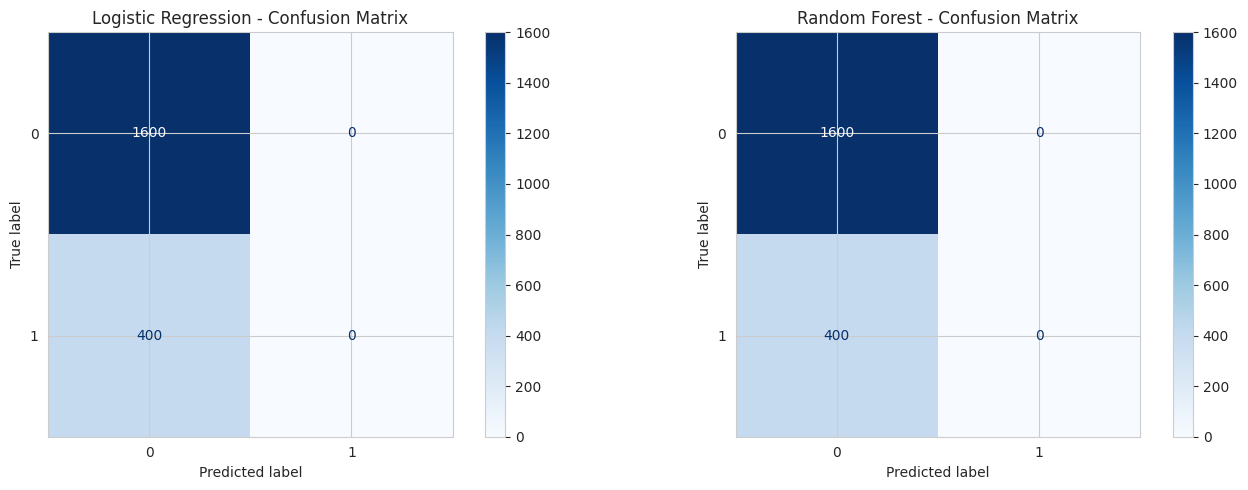

In [ ]:
# Confusion Matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression - Confusion Matrix', fontsize=12)

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest - Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()

**Initial Observation:** The comparison table and confusion matrices above show which model performs better on the initial metrics. The Random Forest Classifier, being an ensemble method, may capture more complex patterns than Logistic Regression.


# Task 4: Hyper-parameter Optimization with Cross-Validation

### 4.1 Hyperparameter Tuning for Logistic Regression

In [ ]:
# Define parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_grid_model = LogisticRegression(max_iter=1000, random_state=42)

# GridSearchCV for Logistic Regression
grid_search_lr = GridSearchCV(
    estimator=lr_grid_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search_lr.fit(X_train_scaled, y_train)

print('=== Logistic Regression - Hyperparameter Tuning ===')
print(f'Best Parameters: {grid_search_lr.best_params_}')
print(f'Best CV Accuracy Score: {grid_search_lr.best_score_:.4f}')

=== Logistic Regression - Hyperparameter Tuning ===
Best Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy Score: 0.8000


### 4.2 Hyperparameter Tuning for Random Forest Classifier

In [ ]:
# Define parameter grid for Random Forest Classifier
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_model = RandomForestClassifier(random_state=42)

# GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    estimator=rf_grid_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search_rf.fit(X_train, y_train)

print('=== Random Forest Classifier - Hyperparameter Tuning ===')
print(f'Best Parameters: {grid_search_rf.best_params_}')
print(f'Best CV Accuracy Score: {grid_search_rf.best_score_:.4f}')

=== Random Forest Classifier - Hyperparameter Tuning ===
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Accuracy Score: 0.8001


### 4.3 Summary of Best Hyperparameters and CV Scores

In [ ]:
print('\n=== Summary of Hyperparameter Optimization ===')
print(f'\nLogistic Regression:')
print(f'  Best Parameters: {grid_search_lr.best_params_}')
print(f'  Best CV Score (Accuracy): {grid_search_lr.best_score_:.4f}')

print(f'\nRandom Forest Classifier:')
print(f'  Best Parameters: {grid_search_rf.best_params_}')
print(f'  Best CV Score (Accuracy): {grid_search_rf.best_score_:.4f}')


=== Summary of Hyperparameter Optimization ===

Logistic Regression:
  Best Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV Score (Accuracy): 0.8000

Random Forest Classifier:
  Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
  Best CV Score (Accuracy): 0.8001



# Task 5: Feature Selection

In [ ]:
# Apply SelectKBest for feature selection
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train, y_train)

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print('Feature Scores (SelectKBest with f_classif):')
print(feature_scores.to_string(index=False))

Feature Scores (SelectKBest with f_classif):
             Feature  F-Score  p-value
                 BMI 7.736348 0.005425
              Gender 4.902279 0.026849
   Sugar Consumption 2.134184 0.144086
                 Age 2.015996 0.155688
 Alcohol Consumption 1.033907 0.309274
High LDL Cholesterol 0.799981 0.371126
        Stress Level 0.768258 0.380783
             Smoking 0.630725 0.427113
         Sleep Hours 0.496516 0.481055
     Exercise Habits 0.435121 0.509506
  Homocysteine Level 0.325851 0.568128
 Fasting Blood Sugar 0.271655 0.602238
      Blood Pressure 0.189279 0.663529
Family Heart Disease 0.120098 0.728937
 Low HDL Cholesterol 0.066115 0.797086
 High Blood Pressure 0.045122 0.831785
            Diabetes 0.003124 0.955427
           CRP Level 0.002991 0.956388
  Triglyceride Level 0.002600 0.959336
   Cholesterol Level 0.000033 0.995387


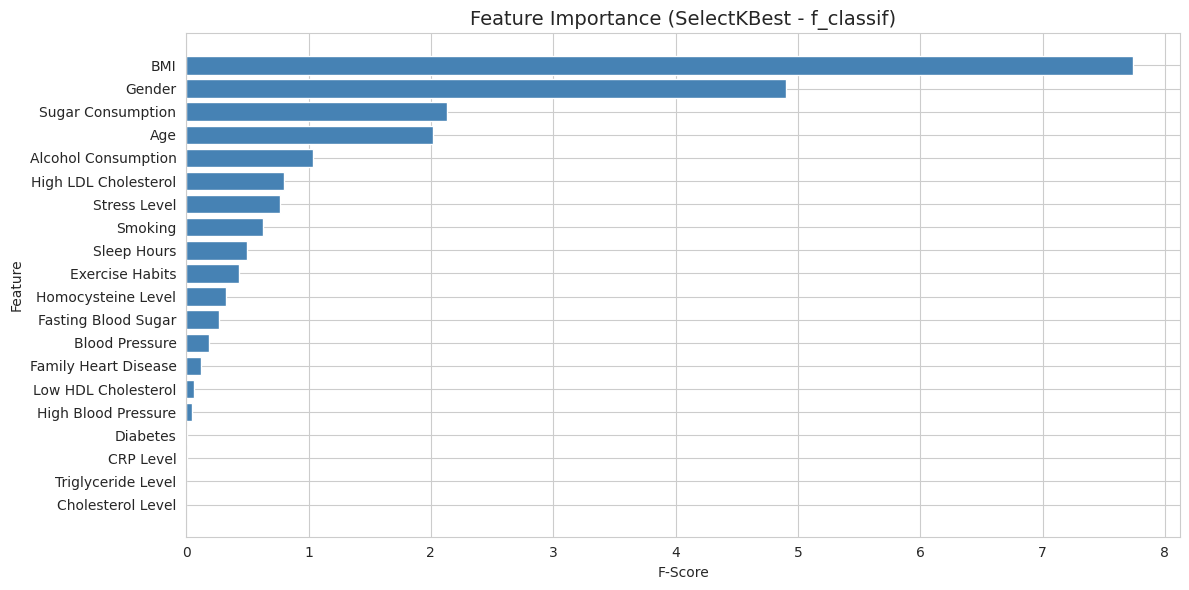

In [ ]:
# Visualize feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_scores['Feature'], feature_scores['F-Score'], color='steelblue')
plt.xlabel('F-Score')
plt.ylabel('Feature')
plt.title('Feature Importance (SelectKBest - f_classif)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Select top features
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()
print(f'\nSelected Features ({len(selected_features)}):')
for i, f in enumerate(selected_features, 1):
    print(f'  {i}. {f}')

# Create new feature sets with selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Scale selected features for Logistic Regression
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)

print(f'\nReduced feature set shape: {X_train_selected.shape}')


Selected Features (10):
  1. Age
  2. Gender
  3. Exercise Habits
  4. Smoking
  5. BMI
  6. High LDL Cholesterol
  7. Alcohol Consumption
  8. Stress Level
  9. Sleep Hours
  10. Sugar Consumption

Reduced feature set shape: (8000, 10)



#Task 6: Final Models and Comparative Analysis

In [ ]:
# Final Model A: Logistic Regression with optimal hyperparameters and selected features
final_lr = LogisticRegression(**grid_search_lr.best_params_, max_iter=1000, random_state=42)
final_lr.fit(X_train_selected_scaled, y_train)

y_pred_lr_final = final_lr.predict(X_test_selected_scaled)

# Cross-validation score for final LR model
cv_scores_lr = cross_val_score(final_lr, X_train_selected_scaled, y_train, cv=5, scoring='accuracy')

print('=== Final Logistic Regression (Model A) ===')
print(f'CV Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})')
print(f'Test Accuracy:  {accuracy_score(y_test, y_pred_lr_final):.4f}')
print(f'Test Precision: {precision_score(y_test, y_pred_lr_final, average="weighted"):.4f}')
print(f'Test Recall:    {recall_score(y_test, y_pred_lr_final, average="weighted"):.4f}')
print(f'Test F1-Score:  {f1_score(y_test, y_pred_lr_final, average="weighted"):.4f}')

=== Final Logistic Regression (Model A) ===
CV Accuracy: 0.8000 (+/- 0.0000)
Test Accuracy:  0.8000
Test Precision: 0.6400
Test Recall:    0.8000
Test F1-Score:  0.7111


In [ ]:
# Final Model B: Random Forest with optimal hyperparameters and selected features
final_rf = RandomForestClassifier(**grid_search_rf.best_params_, random_state=42)
final_rf.fit(X_train_selected, y_train)

y_pred_rf_final = final_rf.predict(X_test_selected)

# Cross-validation score for final RF model
cv_scores_rf = cross_val_score(final_rf, X_train_selected, y_train, cv=5, scoring='accuracy')

print('=== Final Random Forest Classifier (Model B) ===')
print(f'CV Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})')
print(f'Test Accuracy:  {accuracy_score(y_test, y_pred_rf_final):.4f}')
print(f'Test Precision: {precision_score(y_test, y_pred_rf_final, average="weighted"):.4f}')
print(f'Test Recall:    {recall_score(y_test, y_pred_rf_final, average="weighted"):.4f}')
print(f'Test F1-Score:  {f1_score(y_test, y_pred_rf_final, average="weighted"):.4f}')

=== Final Random Forest Classifier (Model B) ===
CV Accuracy: 0.7979 (+/- 0.0006)
Test Accuracy:  0.7970
Test Precision: 0.6395
Test Recall:    0.7970
Test F1-Score:  0.7096


In [ ]:
# Final Comparison Table (as per Table 4 in instructions)
final_comparison = pd.DataFrame({
    'Model': ['Logistic Regression (Model A)', 'Random Forest Classifier (Model B)'],
    'Features': [f'Selected ({len(selected_features)})', f'Selected ({len(selected_features)})'],
    'CV Score': [cv_scores_lr.mean(), cv_scores_rf.mean()],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_final),
        accuracy_score(y_test, y_pred_rf_final)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr_final, average='weighted'),
        precision_score(y_test, y_pred_rf_final, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr_final, average='weighted'),
        recall_score(y_test, y_pred_rf_final, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr_final, average='weighted'),
        f1_score(y_test, y_pred_rf_final, average='weighted')
    ]
})

print('\n=== Table: Comparison of Final Classification Models ===')
print(final_comparison.to_string(index=False))


=== Table: Comparison of Final Classification Models ===
                             Model      Features  CV Score  Accuracy  Precision  Recall  F1-Score
     Logistic Regression (Model A) Selected (10)  0.800000     0.800   0.640000   0.800  0.711111
Random Forest Classifier (Model B) Selected (10)  0.797875     0.797   0.639519   0.797  0.709627


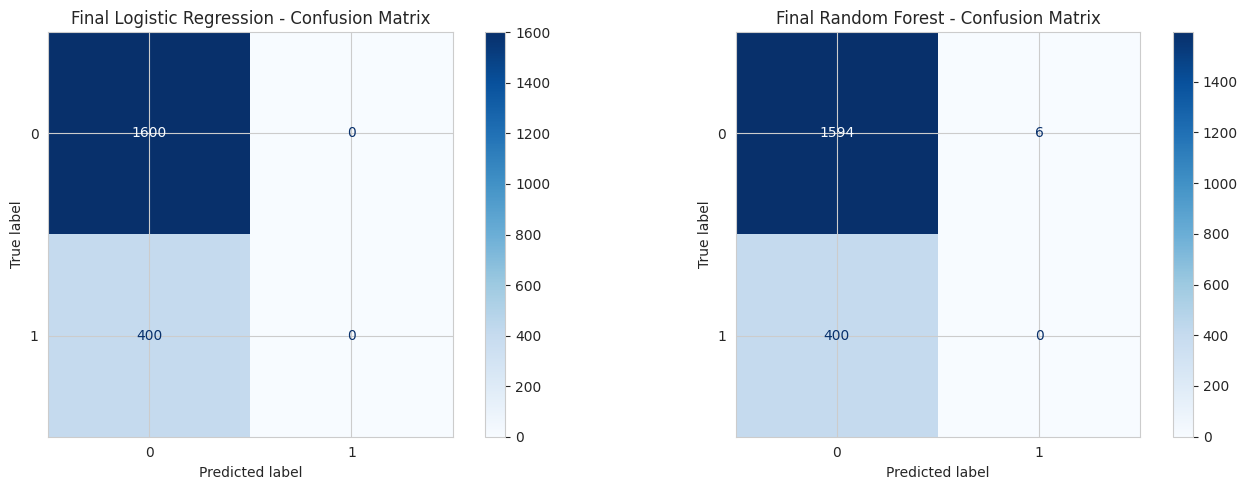

In [ ]:
# Final Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr_final = confusion_matrix(y_test, y_pred_lr_final)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr_final)
disp_lr.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Final Logistic Regression - Confusion Matrix', fontsize=12)

cm_rf_final = confusion_matrix(y_test, y_pred_rf_final)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf_final)
disp_rf.plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Final Random Forest - Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()